In [1]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load and explore the Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of dataset:")
print(df.head())

print("\nDataset Information:") 
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nSpecies Distribution:")
print(df['species_name'].value_counts())

Dataset Shape: (150, 6)

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal l

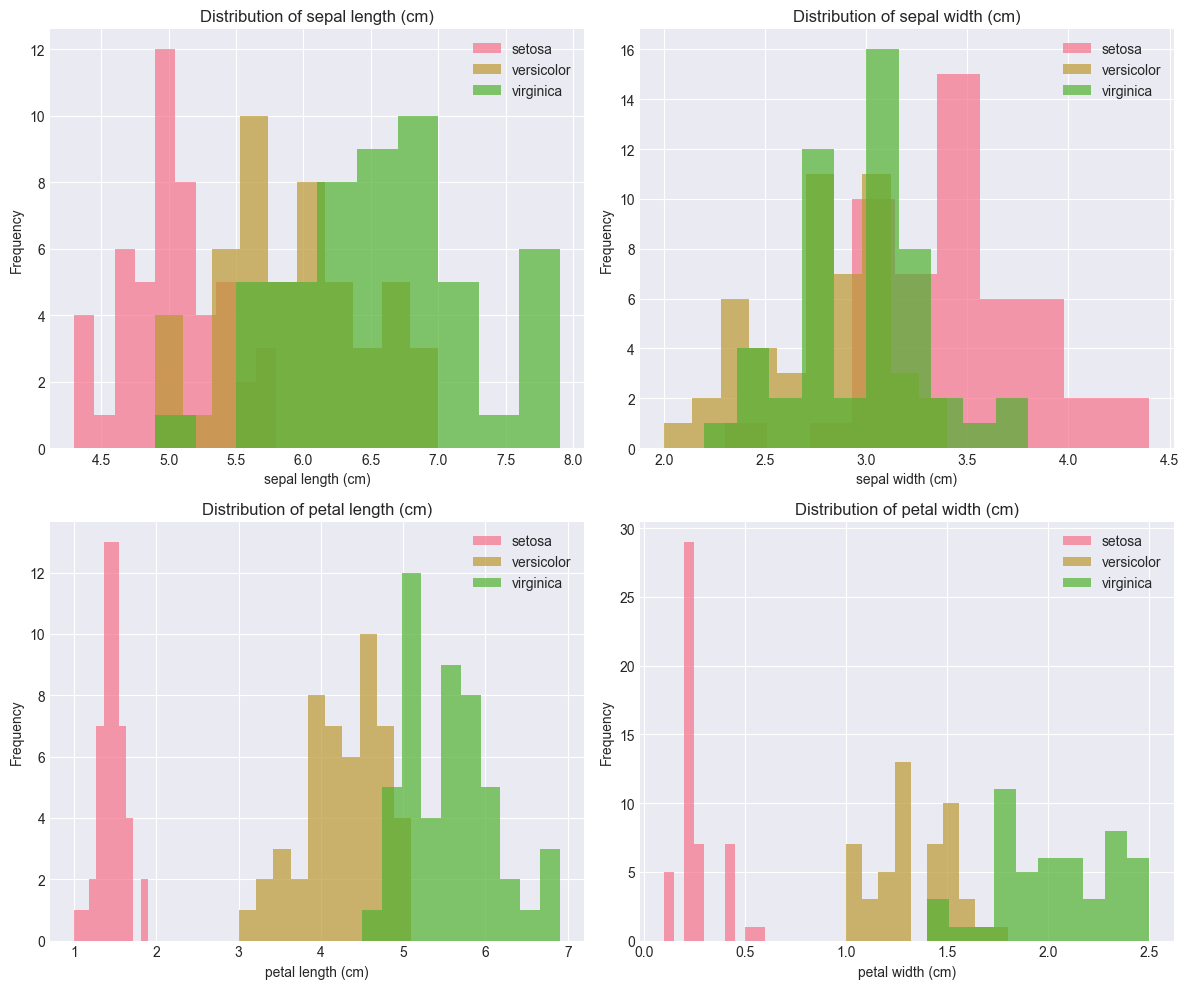

In [3]:
# Cell 3: Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of features
for idx, feature in enumerate(iris.feature_names):
    row, col = idx // 2, idx % 2
    axes[row, col].hist(df[df['species_name']=='setosa'][feature], alpha=0.7, label='setosa')
    axes[row, col].hist(df[df['species_name']=='versicolor'][feature], alpha=0.7, label='versicolor')
    axes[row, col].hist(df[df['species_name']=='virginica'][feature], alpha=0.7, label='virginica')
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

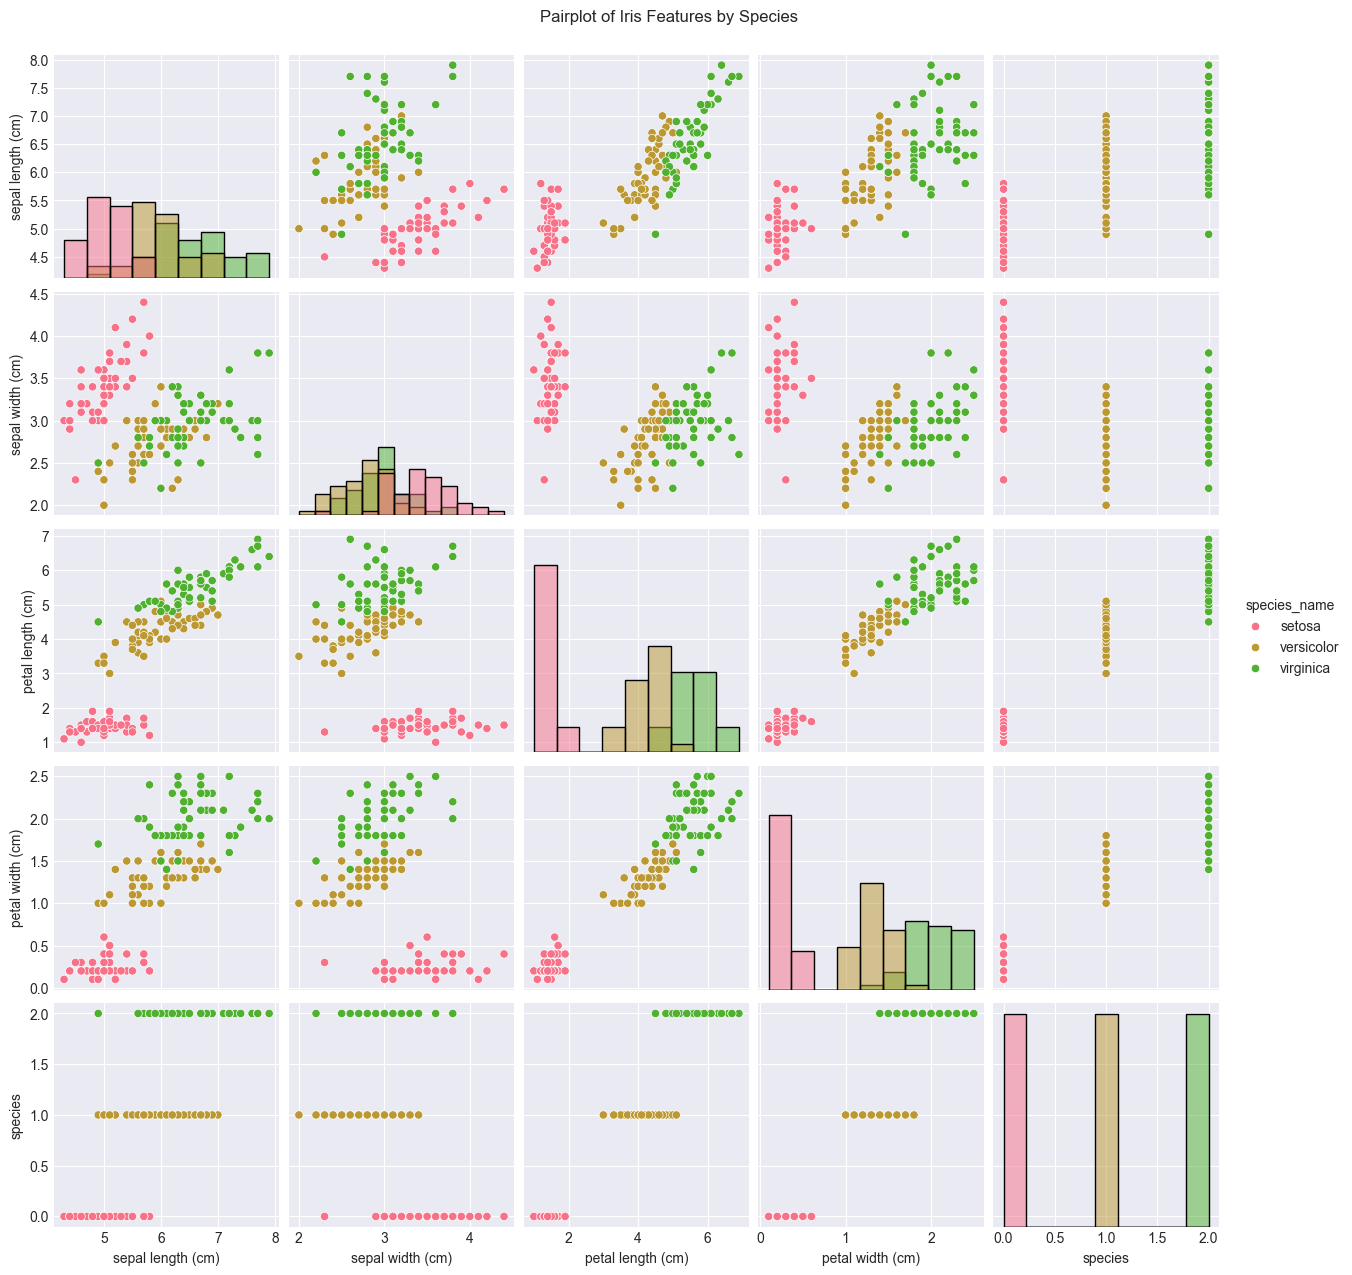

In [4]:
# Cell 4: Pairplot for feature relationships
fig = plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species_name', diag_kind='hist')
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()

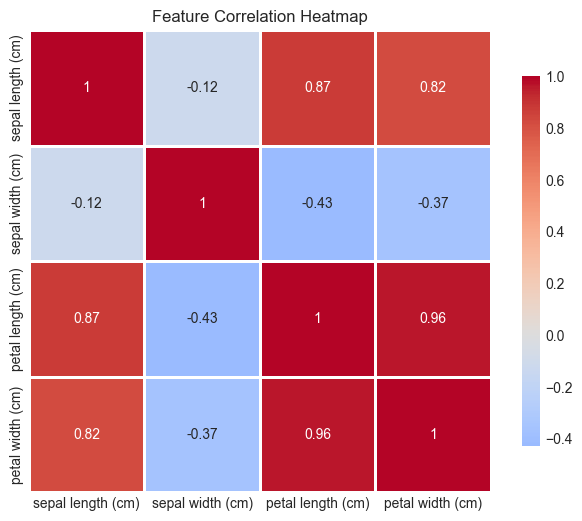

In [5]:
# Cell 5: Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[iris.feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.show()

#     

# Logistic Regression Model


In [ ]:
# Cell 8: Train Logistic Regression Model
print("="*50)
print("LOGISTIC REGRESSION MODEL")
print("="*50)

# Initialize and train
lr_model = LogisticRegression(max_iter=200, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print(f"\nAccuracy: {lr_accuracy:.4f}")
print(f"F1-Score: {lr_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=iris.target_names))

# Cross-validation
cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5)
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

LOGISTIC REGRESSION MODEL




# Random Forest Model

In [ ]:
# Cell 9: Train Random Forest Model
print("="*50)
print("RANDOM FOREST MODEL")
print("="*50)

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaling

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print(f"\nAccuracy: {rf_accuracy:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=iris.target_names))

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Support Vector Classifier (SVC) Model

In [ ]:
# Cell 10: Train SVC Model
print("="*50)
print("SUPPORT VECTOR CLASSIFIER (SVC) MODEL")
print("="*50)

# Initialize and train
svc_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_model.fit(X_train_scaled, y_train)

# Predictions
svc_pred = svc_model.predict(X_test_scaled)

# Evaluate
svc_accuracy = accuracy_score(y_test, svc_pred)
svc_f1 = f1_score(y_test, svc_pred, average='weighted')

print(f"\nAccuracy: {svc_accuracy:.4f}")
print(f"F1-Score: {svc_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, svc_pred, target_names=iris.target_names))

# Cross-validation
cv_scores = cross_val_score(svc_model, X_train_scaled, y_train, cv=5)
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

 # Model Comparison

In [ ]:
# Cell 11: Compare all models
models = ['Logistic Regression', 'Random Forest', 'SVC']
accuracies = [lr_accuracy, rf_accuracy, svc_accuracy]
f1_scores = [lr_f1, rf_f1, svc_f1]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies,
    'F1-Score': f1_scores
})

print("MODEL COMPARISON SUMMARY")
print("="*50)
print(comparison_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy comparison
bars1 = axes[0].bar(models, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_ylim(0.9, 1.02)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{acc:.4f}', ha='center', fontweight='bold')

# F1-Score comparison
bars2 = axes[1].bar(models, f1_scores, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_ylim(0.9, 1.02)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Model F1-Score Comparison')
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{f1:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Confusion Matrices of All Models

In [ ]:
# Cell 12: Confusion matrices visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_predictions = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('SVC', svc_pred)
]

for idx, (name, pred) in enumerate(models_predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Save the Best Model

In [ ]:
# Cell 13: Save the best performing model
import joblib

# Determine best model based on accuracy
best_model_name = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")

# Save the best model
if best_model_name == 'Logistic Regression':
    joblib.dump(lr_model, 'best_iris_model_lr.pkl')
    best_model = lr_model
    scaled = True
elif best_model_name == 'Random Forest':
    joblib.dump(rf_model, 'best_iris_model_rf.pkl')
    best_model = rf_model
    scaled = False
else:
    joblib.dump(svc_model, 'best_iris_model_svc.pkl')
    best_model = svc_model
    scaled = True

# Save the scaler if needed
if scaled:
    joblib.dump(scaler, 'scaler.pkl')

print(f"\nModel saved as 'best_iris_model_{best_model_name[:2].lower()}.pkl'")
print("\nTo load and use the model later:")
print("import joblib")
print("model = joblib.load('best_iris_model_lr.pkl')")